In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
%matplotlib inline

In [4]:
# Генерация данных
print("Генерирация данных...")
n_samples = 20000
X = np.random.uniform(-10, 10, (n_samples, 2))  # 2 входа: x и y
x, y = X[:, 0], X[:, 1]

Генерирация данных...


In [5]:
# Целевая функция: sin(x + 2*y) * exp(-(2x + y)^2)
target = np.sin(x + 2*y) * np.exp(-(2*x + y)**2)
target = target.reshape(-1, 1)

In [6]:
print(f"Размер датасета: {X.shape}")
print(f"Диапазон значений функции: [{target.min():.3f}, {target.max():.3f}]")

Размер датасета: (20000, 2)
Диапазон значений функции: [-0.999, 0.998]


In [7]:
# Разделение на train/val/test (70/15/15)
X_temp, X_test, y_temp, y_test = train_test_split(X, target, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)  # 15/(70+15)=0.1765

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (13999, 2), Val: (3001, 2), Test: (3000, 2)


In [10]:
# Преобразование в PyTorch тензоры
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

print(f"Train={X_train.shape}, Test={X_test.shape}")

Train=(13999, 2), Test=(3000, 2)


In [11]:
# Создание модели
class RegressionModel(nn.Module):
    def __init__(self):
        super(RegressionModel, self).__init__()
        self.fc1 = nn.Linear(2, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 16)
        self.fc5 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.relu(self.fc4(x))
        x = self.fc5(x)
        return x

In [13]:
# Инициализация модели, функции потерь и оптимизатора
model = RegressionModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

print("\nОбучение модели...")


Обучение модели...


In [14]:
# Обучение модели
num_epochs = 200
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Forward pass
    train_pred = model(X_train_tensor)
    train_loss = criterion(train_pred, y_train_tensor)
    
    # Backward pass
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()
    
    # Validation
    with torch.no_grad():
        val_pred = model(X_val_tensor)
        val_loss = criterion(val_pred, y_val_tensor)
    
    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss.item():.6f}, Val Loss: {val_loss.item():.6f}')


Epoch [20/200], Train Loss: 0.016851, Val Loss: 0.015518
Epoch [40/200], Train Loss: 0.016493, Val Loss: 0.015222
Epoch [60/200], Train Loss: 0.015893, Val Loss: 0.014661
Epoch [80/200], Train Loss: 0.015047, Val Loss: 0.013919
Epoch [100/200], Train Loss: 0.014181, Val Loss: 0.013192
Epoch [120/200], Train Loss: 0.013492, Val Loss: 0.012637
Epoch [140/200], Train Loss: 0.012890, Val Loss: 0.012170
Epoch [160/200], Train Loss: 0.012423, Val Loss: 0.011890
Epoch [180/200], Train Loss: 0.011999, Val Loss: 0.011615
Epoch [200/200], Train Loss: 0.011573, Val Loss: 0.011539


In [15]:
# Расчет MSE на test
with torch.no_grad():
    test_pred = model(X_test_tensor)
    test_mse = criterion(test_pred, y_test_tensor).item()
    print(f"\n**Результат a)**")
    print(f"MSE на test: {test_mse:.6f}")


**Результат a)**
MSE на test: 0.011100


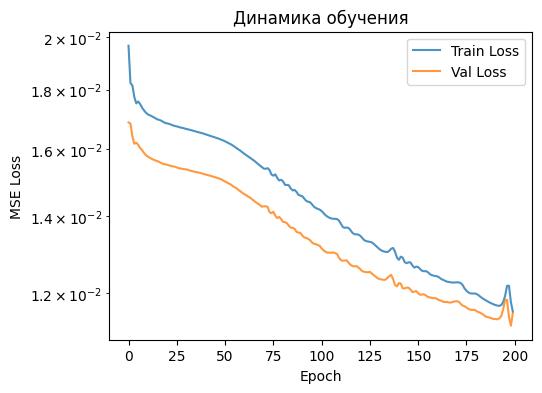

In [17]:
# Визуализация результатов обучения

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', alpha=0.8)
plt.plot(val_losses, label='Val Loss', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Динамика обучения')
plt.yscale('log')

In [29]:
# График сравнения истинной функции и предсказаний

# Предсказания модели
with torch.no_grad():
    pred_grid = model(X_grid_tensor).numpy().reshape(100, 100)

# ИСТИННАЯ ФУНКЦИЯ
true_grid = np.sin(xx + 2*yy) * np.exp(-(2*xx + yy)**2)

print(f"Значения true_grid: min={true_grid.min():.3f}, max={true_grid.max():.3f}")
print(f"Значения pred_grid:  min={pred_grid.min():.3f}, max={pred_grid.max():.3f}")

Значения true_grid: min=-0.990, max=0.990
Значения pred_grid:  min=-0.625, max=0.977


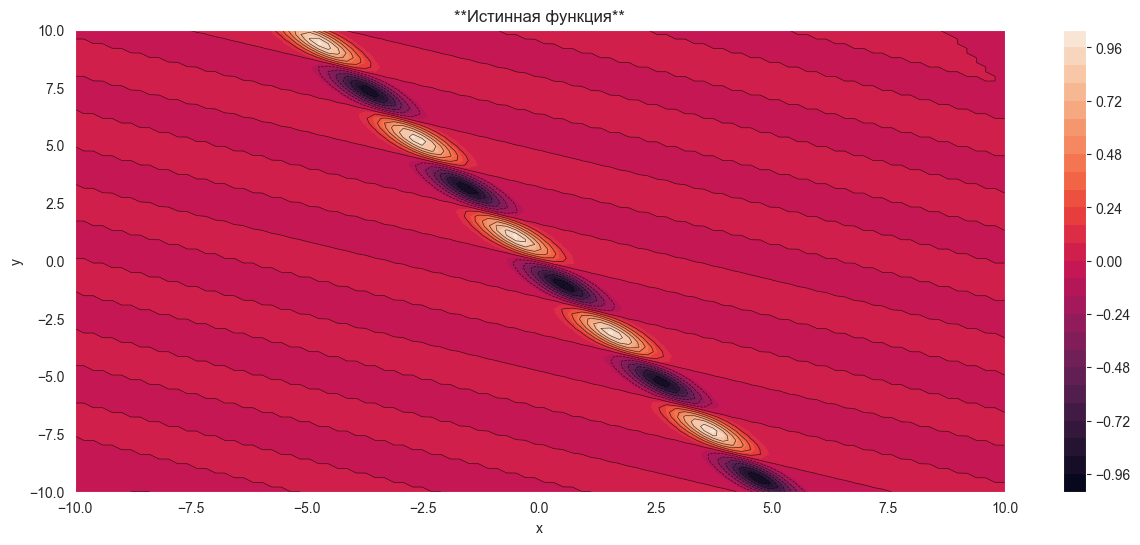

In [34]:
# ГРАФИКИ НА RIGHT SUBPLOT

fig, (ax1) = plt.subplots(1, figsize=(15, 6))

ax1.contourf(xx, yy, true_grid, levels=30, cmap='RdBu_r', alpha=0.8)
ax1.contour(xx, yy, true_grid, levels=15, colors='black', linewidths=0.5, alpha=0.7)
ax1.set_title('**Истинная функция**')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
cbar1 = plt.colorbar(ax1.contourf(xx, yy, true_grid, levels=30), ax=ax1)

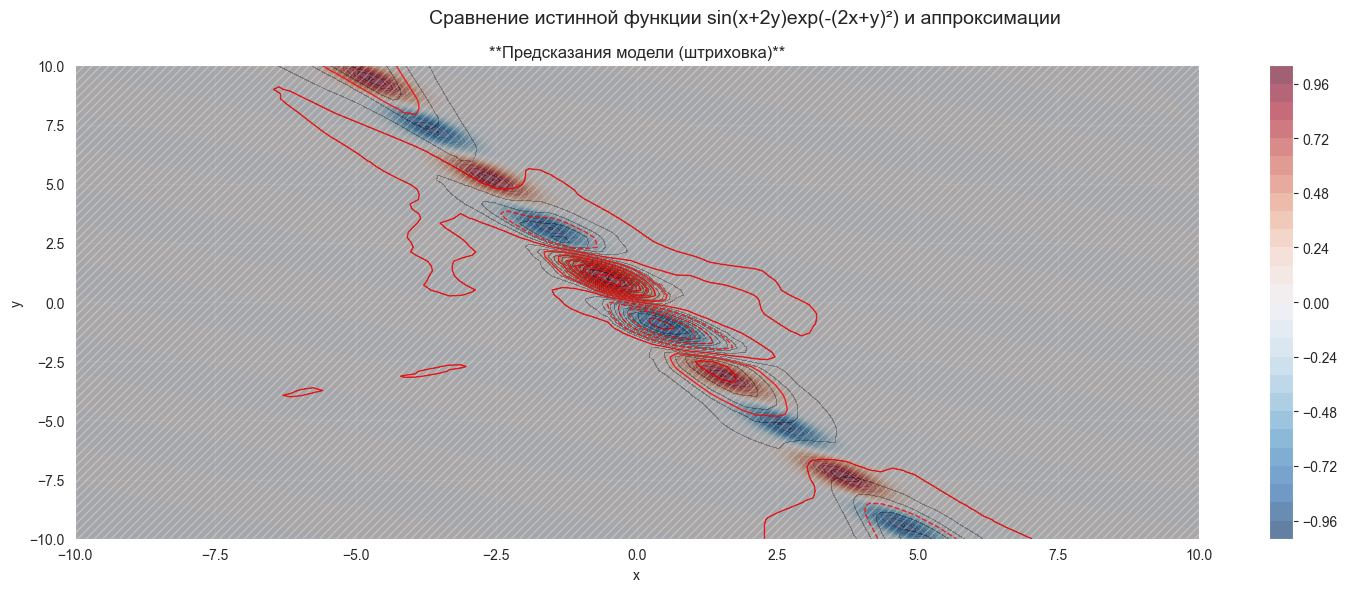

In [36]:
# Предсказания с штриховкой

fig, (ax2) = plt.subplots(1, figsize=(15, 6))

contour_true = ax2.contourf(xx, yy, true_grid, levels=30, cmap='RdBu_r', alpha=0.6)
contour_pred = ax2.contourf(xx, yy, pred_grid, levels=30, hatches=['////'], colors='none', alpha=0.3)
ax2.contour(xx, yy, pred_grid, levels=15, colors='red', linewidths=1, alpha=0.8)
ax2.set_title('**Предсказания модели (штриховка)**')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
cbar2 = plt.colorbar(contour_true, ax=ax2)

plt.suptitle('Сравнение истинной функции sin(x+2y)exp(-(2x+y)²) и аппроксимации', fontsize=14)
plt.tight_layout()
plt.show()

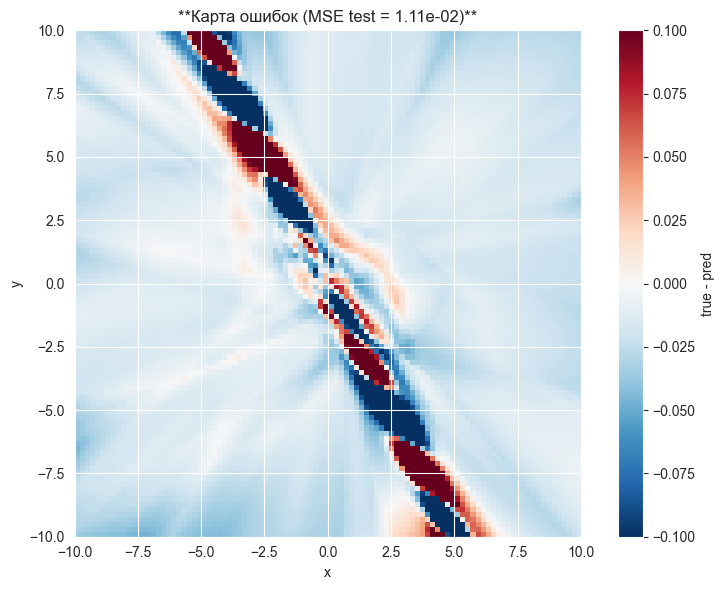

Диапазон ошибок: -1.117 ... 1.046


In [38]:
# КАРТА ОШИБОК
fig_err, ax_err = plt.subplots(1, 1, figsize=(8, 6))
error_grid = true_grid - pred_grid
im = ax_err.imshow(error_grid, extent=[-10, 10, -10, 10], origin='lower', cmap='RdBu_r', vmin=-0.1, vmax=0.1)
ax_err.set_xlabel('x')
ax_err.set_ylabel('y')
ax_err.set_title(f'**Карта ошибок (MSE test = {test_mse:.2e})**')
plt.colorbar(im, ax=ax_err, label='true - pred')
plt.tight_layout()
plt.show()

print(f"Диапазон ошибок: {error_grid.min():.3f} ... {error_grid.max():.3f}")